## 🌐 Network Generation for Percolation Dynamics

To begin, generate a network of interest on which you wish to apply percolation dynamics. For demonstration purposes, we consider a synthetic network generated using the Watts–Strogatz model. With minor adjustments to the function below, it is possible to construct a wide variety of network topologies and subsequently explore the percolation process step by step.

### 📚 Importing Libraries

In [ ]:
# 📦 Core Libraries
import os
import time
import math
import random
from pathlib import Path

# 📊 Data Handling
import pandas as pd

# 🌐 Graphs & Networks
import networkx as nx

## 🛰️ Generating the Network

To facilitate the understanding of percolation, we will provide three synthetic networks, Erdős–Rényi, Watts–Strogatz and Hub-and-spoke topology on which the implemented percolation will be applied.

In [2]:
def generate_ws_graph(N: int, k: int, p: float, seed: int | None = None) -> nx.Graph:
    """
    Generate a Small-World network using the Watts–Strogatz model.

    Parameters
    ----------
    N : int
        Number of nodes.
    k : int
        Each node is connected to k nearest neighbors in a ring topology (must be even).
    p : float
        Probability of rewiring each edge (0 = regular lattice, 1 = random network).
    seed : int | None
        Optional seed for reproducibility.

    Returns
    -------
    networkx.Graph
        The generated Watts–Strogatz small-world graph.
    """
    if k % 2 != 0:
        raise ValueError("Parameter k must be even in the Watts–Strogatz model.")

    G = nx.watts_strogatz_graph(N, k, p, seed=seed)
    
    return G



def generate_er_graph(N: int, avg_k: float, seed: int | None = None) -> nx.Graph:
    """
    Generate an Erdős–Rényi random graph G(n, p).

    Parameters
    ----------
    N : int
        Number of nodes.
    avg_k : float
        Target average degree. Used to compute the edge probability as p = avg_k / (N - 1).
    seed : int | None
        Optional seed for reproducibility.

    Returns
    -------
    networkx.Graph
        The generated Erdős–Rényi random graph.
    """
    if N < 2:
        raise ValueError("N must be >= 2")

    # probability of edge creation
    p = avg_k/(N-1)

    G = nx.gnp_random_graph(N, p, seed=seed, directed=False)
    
    return G


def generate_generalized_star(N: int, extra_edge_prob: float = 0.02, seed: int | None = None) -> nx.Graph:
    """
    Generate a Generalized Star Network:
    - One central node connected to all others (classic star structure).
    - Additional edges are randomly added between leaf nodes.

    Parameters
    ----------
    N : int
        Total number of nodes (>= 2).
    extra_edge_prob : float
        Probability of adding an edge between two leaves (0 <= p <= 1).
    seed : int | None
        Random seed for reproducibility (default=None).

    Returns
    -------
    networkx.Graph
        Graph with a generalized star structure.
    """
    if N < 2:
        raise ValueError("N must be >= 2")

    if seed is not None:
        random.seed(seed)

    # Create classic star (node 0 is the central hub)
    G = nx.star_graph(N - 1)

    # Add extra edges between leaves
    leaves = list(range(1, N))
    for i in range(len(leaves)):
        for j in range(i + 1, len(leaves)):
            if random.random() < extra_edge_prob:
                G.add_edge(leaves[i], leaves[j])

    return G


def save_graph_as_txt(G: nx.Graph,
                      out_dir: str = "network-save",
                      filename: str = "graph.txt",
                      one_indexed: bool = True,
                      preserve_isolated: bool = True) -> str:
    """
    Save the graph in edge list format (u v).  
    If preserve_isolated=True, writes a self-loop (i i) for each isolated node,  
    ensuring that all nodes are included in the file.
    """
    os.makedirs(out_dir, exist_ok=True)
    path = Path(out_dir) / filename
    with open(path, "w", encoding="utf-8") as f:
        for u, v in G.edges():
            u = u + 1 if one_indexed else u
            v = v + 1 if one_indexed else v
            f.write(f"{u} {v}\n")
        if preserve_isolated:
            for n in G.nodes():
                if G.degree(n) == 0:
                    i = n + 1 if one_indexed else n
                    f.write(f"{i} {i}\n")
    return str(path)

### 🖼️ Example Usage and Plot (Erdős–Rényi)

In [3]:
# Define network size (N) and average degree (avg_k)
N, avg_k = 1500, 4

# Generate an Erdős–Rényi random graph with the given parameters
G_er = generate_er_graph(N, avg_k)

# Save the generated graph as an edge list in a .txt file
save_graph_as_txt(G_er, out_dir="network-save", filename="er1500-graph.txt")

'network-save\\er1500-graph.txt'

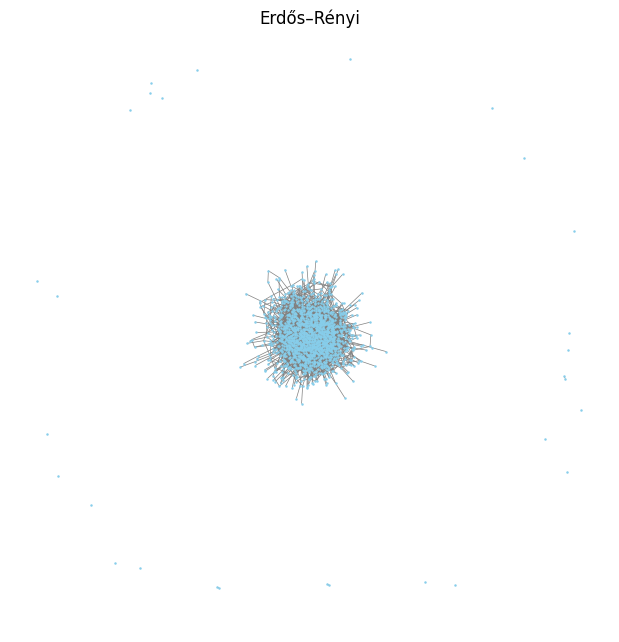

In [4]:
# Plot the network
plt.figure(figsize=(6, 6))
pos = nx.spring_layout(G_er, seed=42) 
nx.draw(G_er, pos, node_size=0.6, node_color="skyblue", edge_color="gray",  width=0.5, with_labels=False)
plt.title("Erdős–Rényi")
plt.show()

### 🖼️ Example Usage and Plot (Watts–Strogatz)

In [5]:
N, k, p = 1500, 2, 0.2
G_ws = generate_ws_graph(N, k, p, seed=42)
# Save the generated graph as an edge list in a .txt file
save_graph_as_txt(G_ws, out_dir="network-save", filename="ws1500-graph.txt")

'network-save\\ws1500-graph.txt'

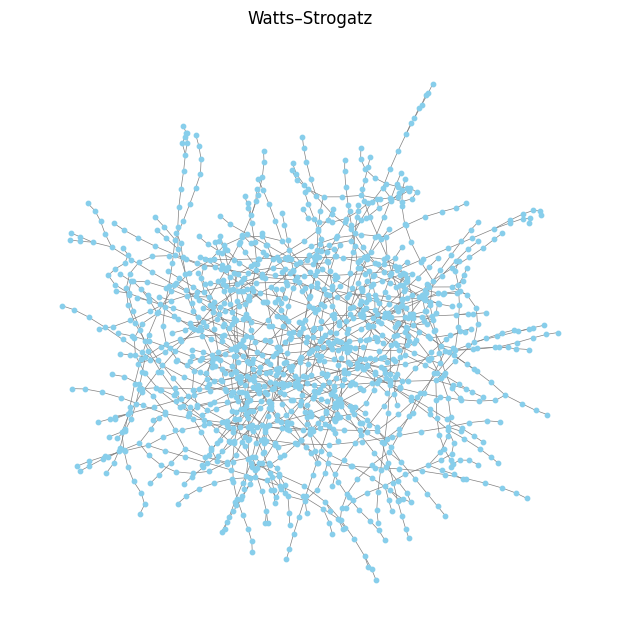

In [6]:
# Plot the network
plt.figure(figsize=(6, 6))
pos = nx.spring_layout(G_ws, seed=42) 
nx.draw(G_ws, pos, node_size=10, node_color="skyblue", edge_color="gray",  width=0.5, with_labels=False)
plt.title("Watts–Strogatz")
plt.show()

### 🖼️ Example Usage and Plot (Hub-and-spoke topology)

In [11]:
N, extra_edge_prob = 1500, 0.001

G_star = generate_generalized_star(N, extra_edge_prob, seed=42)
save_graph_as_txt(G_er, out_dir="network-save", filename="star1500-graph.txt")

'network-save\\star1500-graph.txt'

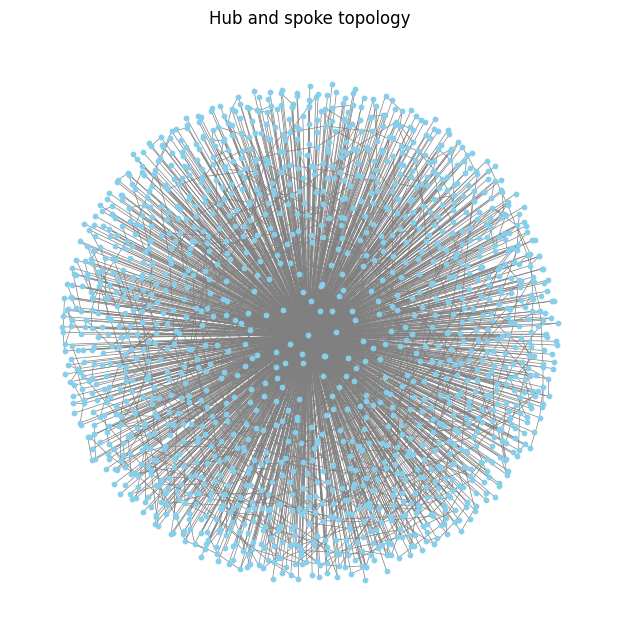

In [12]:
# Plot the network
plt.figure(figsize=(6, 6))
pos = nx.spring_layout(G_star, seed=42) 
nx.draw(G_star, pos, node_size=10, node_color="skyblue", edge_color="gray",  width=0.5, with_labels=False)
plt.title("Hub and spoke topology")
plt.show()

After saving the network in the network-save folder, you can start the percolation process. It is not necessary to generate the network directly in the code: if you already have a network in .txt format, simply place it in the mentioned folder.

### 🔗 Converting a Graph to BOND Representation  

The `network_to_bond` function transforms a **NetworkX graph** into a **BOND structure**, a 1-indexed adjacency format commonly used in percolation algorithms.  

#### 📝 How it works  
- **`bond[0][i]`** → stores the degree of node *i*  
- **`bond[i]`** → list containing `[0, neighbor1, neighbor2, ...]`  
- **1-indexed** → nodes start at index **1** instead of **0**  


In [3]:
def read_network_from_txt(path, one_indexed=False, remove_selfloops=True):
    """
    Read a graph from a .txt file in edge list format.

    Parameters
    ----------
    path : str
        Path to the text file containing the network edges.
        Each line must follow the format: "i j".
    one_indexed : bool, optional
        If True, node IDs in the file are 1-indexed and will be shifted
        to 0-index internally. Default = False.
    remove_selfloops : bool, optional
        If True, removes self-loops (edges i i) after reading.

    Returns
    -------
    networkx.Graph
        Graph reconstructed from the edge list file.
    """
    G = nx.Graph()
    with open(path, "r") as f:
        for line in f:
            if not line.strip():
                continue
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            i, j = map(int, parts[:2])
            if one_indexed:
                i, j = i - 1, j - 1
            G.add_edge(i, j)

    if remove_selfloops:
        G.remove_edges_from(nx.selfloop_edges(G))

    return G



def network_to_bond(G):
    """
    Convert a NetworkX graph into a 'bond' adjacency structure.

    Parameters
    ----------
    G : networkx.Graph
        Graph to convert. Node IDs must be consecutive integers.

    Returns
    -------
    tuple
        bond : list
            Bond representation of the graph where:
            - bond[0][i] = degree of node i
            - bond[i] = [0, neighbor1, neighbor2, ...]
        N : int
            Number of nodes in the graph.

    Notes
    -----
    The resulting bond structure is 1-indexed to match
    percolation algorithm conventions.
    """
    nodes = sorted(G.nodes())
    id_map = {old: i+1 for i, old in enumerate(nodes)}
    N = len(nodes)

    bond = [None] * (N + 1)
    bond[0] = [0] * (N + 1)
    for i in range(1, N + 1):
        bond[i] = [0]

    for (u, v) in G.edges():
        i1 = id_map[u]
        j1 = id_map[v]
        bond[0][i1] += 1
        bond[0][j1] += 1
        bond[i1].append(j1)
        bond[j1].append(i1)

    return bond, N


### 🔢 Mersenne Twister 64-bit (placeholder usando Python's random)

In [4]:
NN = 312
mt = [0] * NN
mti = 0

def genrand64_int64():
    """
    Generate a pseudo-random 64-bit integer.

    Notes
    -----
    This is a placeholder implementation using Python's built-in RNG.
    """
    return random.getrandbits(64)

def genrand64_real3():
    """
    Generate a random float in the interval [0, 1).
    """
    return genrand64_int64() / float(1 << 64)

def init_genrand64(seed: int):
    """
    Initialize the placeholder state for MT19937-64 
    and synchronize Python's RNG with the given seed.
    """
    global mt, mti
    random.seed(seed)
    mt[0] = seed
    for mti in range(1, NN):
        mt[mti] = (6364136223846793005 * (mt[mti-1] ^ (mt[mti-1] >> 62)) + mti) & ((1 << 64) - 1)

def random_attack_node(N: int):
    """
    Select a random node uniformly from the set {1, ..., N}.
    """
    return int(genrand64_real3() * N) + 1


### 🛠️ Utilities for BOND Structures and Centrality

In [5]:
def bond_to_graph(bond, N):
    """
    Convert a 'bond' adjacency structure into a NetworkX graph.

    Parameters
    ----------
    bond : list
        Bond representation of the network (adjacency structure).
    N : int
        Number of nodes.

    Returns
    -------
    networkx.Graph
        Graph converted from the bond representation.
    """
    G = nx.Graph()
    G.add_nodes_from(range(1, N + 1))
    for i in range(1, N + 1):
        for idx in range(1, bond[0][i] + 1):
            j = bond[i][idx]
            if i < j:
                G.add_edge(i, j)
    return G


def get_hub_nodes(N, bond, top_k=1):
    """
    Identify the top-k hub nodes ranked by degree.

    Parameters
    ----------
    N : int
        Number of nodes.
    bond : list
        Bond representation of the network.
    top_k : int, optional
        Number of top hub nodes to return (default = 1).

    Returns
    -------
    list
        List of node IDs corresponding to the top-k hubs.
    """
    degree_list = [(bond[0][i], i) for i in range(1, N + 1)]
    degree_list.sort(key=lambda x: x[0], reverse=True)
    return [i for _, i in degree_list[:top_k]]


def select_hub_node(N, bond, top_k=1):
    """
    Randomly select one node from the top-k hubs.

    Parameters
    ----------
    N : int
        Number of nodes.
    bond : list
        Bond representation of the network.
    top_k : int, optional
        Number of top hub nodes considered for selection (default = 1).

    Returns
    -------
    int or None
        ID of the selected hub node, or None if no hubs exist.
    """
    hubs = get_hub_nodes(N, bond, top_k=top_k)
    return random.choice(hubs) if hubs else None


def get_closeness_nodes(N, bond, top_k=1):
    """
    Identify the top-k nodes ranked by closeness centrality.

    Parameters
    ----------
    N : int
        Number of nodes.
    bond : list
        Bond representation of the network.
    top_k : int, optional
        Number of nodes to return (default = 1).

    Returns
    -------
    list
        List of node IDs with the highest closeness centrality.
    """
    G = bond_to_graph(bond, N)
    clos = nx.closeness_centrality(G)
    ordered = sorted(clos.items(), key=lambda kv: kv[1], reverse=True)
    return [n for n, _ in ordered[:top_k]]


def select_closeness_node(N, bond, top_k=1):
    """
    Randomly select one node among the top-k by closeness centrality.

    Parameters
    ----------
    N : int
        Number of nodes.
    bond : list
        Bond representation of the network.
    top_k : int, optional
        Number of nodes considered for selection (default = 1).

    Returns
    -------
    int or None
        ID of the selected node, or None if no nodes exist.
    """
    nodes = get_closeness_nodes(N, bond, top_k=top_k)
    return random.choice(nodes) if nodes else None


def get_betweenness_nodes(N, bond, top_k=1, normalized=True):
    """
    Identify the top-k nodes ranked by betweenness centrality.

    Parameters
    ----------
    N : int
        Number of nodes.
    bond : list
        Bond representation of the network.
    top_k : int, optional
        Number of nodes to return (default = 1).
    normalized : bool, optional
        Whether to normalize betweenness values (default = True).

    Returns
    -------
    list
        List of node IDs with the highest betweenness centrality.
    """
    G = bond_to_graph(bond, N)
    btw = nx.betweenness_centrality(G, normalized=normalized)
    ordered = sorted(btw.items(), key=lambda kv: kv[1], reverse=True)
    return [n for n, _ in ordered[:top_k]]


def select_betweenness_node(N, bond, top_k=1, normalized=True):
    """
    Randomly select one node among the top-k by betweenness centrality.

    Parameters
    ----------
    N : int
        Number of nodes.
    bond : list
        Bond representation of the network.
    top_k : int, optional
        Number of nodes considered for selection (default = 1).
    normalized : bool, optional
        Whether to normalize betweenness values (default = True).

    Returns
    -------
    int or None
        ID of the selected node, or None if no nodes exist.
    """
    nodes = get_betweenness_nodes(N, bond, top_k=top_k, normalized=normalized)
    return random.choice(nodes) if nodes else None


def find_node(i, j, bond):
    """
    Find the neighbor index of node j in the adjacency list of node i.

    Parameters
    ----------
    i : int
        Node whose neighbors will be searched.
    j : int
        Target node to find in the adjacency list.
    bond : list
        Bond representation of the network.

    Returns
    -------
    int
        Index position of node j in the adjacency list of node i
        (1..degree(i)) or -1 if not found.
    """
    for k in range(1, bond[0][i] + 1):
        if bond[i][k] == j:
            return k
    return -1

def copy_network(N, origin_bond, copy_bond):
    """
    Copy node degrees and adjacency lists from one bond structure to another.

    Parameters
    ----------
    N : int
        Number of nodes.
    origin_bond : list
        Source bond structure.
    copy_bond : list
        Destination bond structure. Must be preallocated with length N+1.
    """
    if len(copy_bond) != N + 1:
        raise ValueError("copy_bond must have size N+1")

    for i in range(1, N + 1):
        deg = origin_bond[0][i]
        if len(copy_bond[0]) <= i:
            copy_bond[0].extend([0] * (i - len(copy_bond[0]) + 1))
        copy_bond[0][i] = deg
        copy_bond[i] = origin_bond[i][:deg + 1]

### 🔍 BFS and Shortest Path Sampling

In [6]:
def clean_time_stamp(update_time, E):
    """
    Reset all timestamps to zero.

    Parameters
    ----------
    update_time : list
        List of timestamps to be reset.
    E : int
        Number of elements (edges or entries) to reset.
    """
    for i in range(1, E+1):
        update_time[i] = 0


def simple_bfs(C, N, bond, source, target, vec, tmp_vec, visited, reset, dag, nr_sp):
    """
    BFS up to depth C or until reaching target.
    """
    int_distance, control = 0, 0
    vec[0], vec[1] = 1, source
    visited[source], dag[0][source], nr_sp[source] = 0, 0, 1
    reset[0], reset[1] = 1, source

    while vec[0] > 0 and control == 0:
        tmp_vec[0] = 0
        int_distance += 1
        if int_distance == C:
            control = 1
        for i in range(1, vec[0] + 1):
            n = vec[i]
            for j in range(1, bond[0][n] + 1):
                m = bond[n][j]
                if m == target:
                    control = 2
                if visited[m] < 0:
                    tmp_vec[0] += 1
                    tmp_vec[tmp_vec[0]] = m
                    visited[m] = visited[n] + 1
                    reset[0] += 1
                    reset[reset[0]] = m
                if visited[m] == int_distance:
                    dag[0][m] += 1
                    dag[m][dag[0][m]] = n
                    nr_sp[m] += nr_sp[n]
        for i2 in range(tmp_vec[0] + 1):
            vec[i2] = tmp_vec[i2]
    return control


def sample_random_path(C, N, dag, source, target, path, nr_sp):
    """
    Sample one shortest path from target to source in the BFS DAG.
    """
    control = 0
    path[0], path[1] = 1, target
    while control == 0:
        n = path[path[0]]
        if dag[0][n] > 0:
            T = sum(nr_sp[dag[n][i]] for i in range(1, dag[0][n] + 1))
            if T == 0:
                path[0] = 0
                return
            q = int(genrand64_real3() * T) + 1
            acc, found = 0, 0
            for i in range(1, dag[0][n] + 1):
                acc += nr_sp[dag[n][i]]
                if q <= acc:
                    found = dag[n][i]
                    break
            path[0] += 1
            path[path[0]] = found
            if path[0] == C + 1 or path[path[0]] == source:
                control = 1
        else:
            path[0] = 0
            return



def get_path_of_pair(source, target, C, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp):
    """
    Compute and sample a shortest path between a source-target pair, limited by C.

    Parameters
    ----------
    source : int
        Starting node.
    target : int
        Target node.
    C : int
        Maximum BFS depth or path length.
    N : int
        Number of nodes.
    bond : list
        Bond adjacency structure.
    path, vec, tmp_vec, visited, reset, dag, nr_sp : list
        Auxiliary arrays for BFS and path sampling.

    Returns
    -------
    int
        Length of the sampled path (path[0]) or 0 if no path exists.
    """
    control = simple_bfs(C, N, bond, source, target, vec, tmp_vec, visited, reset, dag, nr_sp)
    path[0] = 0
    if control == 2:
        sample_random_path(C, N, dag, source, target, path, nr_sp)
    for i in range(1, reset[0] + 1):
        node = reset[i]
        visited[node] = -1
        dag[0][node] = 0
        nr_sp[node] = 0
    return path[0]

### 🎲 Other Auxiliary Routines

In [7]:
def geometric_distribution(P: float):
    """
    Sample from a geometric distribution with parameter P.

    Parameters
    ----------
    P : float
        Success probability of the geometric distribution (0 < P ≤ 1).

    Returns
    -------
    int
        Sampled value k ≥ 1 with probability (1-P)^(k-1) * P.
        Returns -1 if P <= 0.

    Notes
    -----
    - If P = 1, the function always returns 1.
    - Sampling is performed using the custom RNG genrand64_real3().
    - This is the "number of trials until first success" variant (support starts at 1).
    """
    if P <= 0:
        return -1
    if P == 1:
        return 1
    u = genrand64_real3()
    return 1 + int(math.floor(math.log(u) / math.log(1.0 - P)))


def adjust_pair(pairs, q: int):
    """
    Move the pair at position q to the end of the active list 
    and decrease the active counter.

    Parameters
    ----------
    pairs : list of lists
        Pair structure:
        - pairs[0] : list of node1 indices (1-indexed).
        - pairs[1] : list of node2 indices (1-indexed).
        - pairs[0][0] : integer counter of currently active pairs.
    q : int
        Index of the pair to be moved (1 <= q <= pairs[0][0]).

    Notes
    -----
    - This function modifies 'pairs' in place.
    - The order of pairs is not preserved (swap-and-pop removal).
    """
    if q < 1 or q > pairs[0][0]:
        raise IndexError("q is out of range of active pairs")

    node1 = pairs[0][q]
    node2 = pairs[1][q]

    # overwrite position q with the last active pair
    pairs[0][q] = pairs[0][pairs[0][0]]
    pairs[1][q] = pairs[1][pairs[0][0]]

    # move removed pair to the end (optional, just to keep it)
    pairs[0][pairs[0][0]] = node1
    pairs[1][pairs[0][0]] = node2

    # decrement active counter
    pairs[0][0] -= 1

### 🎯 Node Selection Strategies (mode + rank)

In [8]:
def ordered_by_degree(nodes, bond):
    """
    Order nodes by degree in descending order.
    
    Parameters
    ----------
    nodes : list[int]
        List of node IDs to sort.
    bond : list
        Bond adjacency structure.
    
    Returns
    -------
    list[int]
        Nodes ordered by degree (highest first).
    """
    return sorted(nodes, key=lambda i: bond[0][i], reverse=True)


def ordered_by_centrality(nodes, bond, N, kind="closeness"):
    """
    Order nodes by a centrality measure in descending order.
    
    Parameters
    ----------
    nodes : list[int]
        List of node IDs to sort.
    bond : list
        Bond adjacency structure.
    N : int
        Number of nodes in the network.
    kind : str, optional
        Centrality type: 'closeness' or 'betweenness'. Default is 'closeness'.
    
    Returns
    -------
    list[int]
        Nodes ordered by centrality (highest first).
    """
    G = bond_to_graph(bond, N)
    if kind == "closeness":
        cent = nx.closeness_centrality(G)
    elif kind == "betweenness":
        cent = nx.betweenness_centrality(G, normalized=True)
    else:
        raise ValueError("centrality kind must be 'closeness' or 'betweenness'")
    return sorted(nodes, key=lambda i: cent[i], reverse=True)


def select_node(N, bond, mode="random", rank=1, exclude=None):
    """
    Select a node based on the given mode and rank.
    
    Parameters
    ----------
    N : int
        Number of nodes in the network.
    bond : list
        Bond adjacency structure.
    mode : str, optional
        Node selection mode: 'random', 'hub', 'closeness', 'betweenness'.
    rank : int, optional
        Rank of the node to select (1 = highest, 2 = second highest, etc.).
    exclude : int or None, optional
        Node to exclude from selection (e.g., already chosen).
    
    Returns
    -------
    int or None
        Selected node ID, or None if no nodes are available.
    """
    nodes = list(range(1, N+1))
    if exclude is not None and exclude in nodes:
        nodes.remove(exclude)
    if not nodes:
        return None

    if mode == "random":
        return random.choice(nodes)

    if mode == "hub":
        ordered = ordered_by_degree(nodes, bond)
    elif mode == "closeness":
        ordered = ordered_by_centrality(nodes, bond, N, kind="closeness")
    elif mode == "betweenness":
        ordered = ordered_by_centrality(nodes, bond, N, kind="betweenness")
    else:
        raise ValueError(f"[ERROR] Unknown attack mode: {mode}")

    idx = min(max(1, rank) - 1, len(ordered) - 1)
    return ordered[idx]

###  🧨 Unified Core of Pair-Removal Attacks

In [9]:
def core_pair_removal_loop(C, N, bond, edges, E, update_time, threshold,
                           attack_mode_1="random", attack_mode_2="random",
                           rank_1=1, rank_2=1):
    """
    Core routine for pair-removal attacks.
    """
    path, vec, tmp_vec = [0] * (N+1), [0] * (N+1), [0] * (N+1)
    visited, reset, nr_sp = [-1] * (N+1), [0] * (N+1), [0] * (N+1)
    dag = [[0] * (N+1 if i == 0 else (bond[0][i] + 1)) for i in range(N+1)]

    count_E, tau, num_failures = 0, 1, 0
    while num_failures < threshold:
        n = select_node(N, bond, mode=attack_mode_1, rank=rank_1)
        m = select_node(N, bond, mode=attack_mode_2, rank=rank_2, exclude=n)
        if n is None or m is None:
            edges[0][0] = 0
            return

        if bond[0][n] > bond[0][m]:
            n, m = m, n

        p = get_path_of_pair(n, m, N if C == -1 else C, N,
                             bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)

        if p > 0:
            num_failures = 0
            for j in range(1, path[0]):
                s, t = path[j], path[j+1]
                v1, v2 = find_node(s, t, bond), find_node(t, s, bond)
                if v1 == -1 or v2 == -1:
                    continue
                bond[s][v1] = bond[s][bond[0][s]]
                bond[0][s] -= 1
                bond[t][v2] = bond[t][bond[0][t]]
                bond[0][t] -= 1

                count_E += 1
                edges[0][count_E], edges[1][count_E] = min(s, t), max(s, t)
                update_time[count_E] += tau
        else:
            num_failures += 1
        tau += 1

    for i in range(count_E + 1, E + 1):
        update_time[i] += tau
    edges[0][0] = count_E

### 🧮 Pair-Based Attack Routines

In [10]:
def remove_pair_w_pair_info_v2(C, N, bond, pairs, edges, update_time):
    """
    Remove edges along shortest paths between precomputed node pairs.
    """
    path, vec, tmp_vec = [0] * (N+1), [0] * (N+1), [0] * (N+1)
    visited, reset, nr_sp = [-1] * (N+1), [0] * (N+1), [0] * (N+1)
    dag = [[0] * (N+1 if i == 0 else (bond[0][i] + 1)) for i in range(N+1)]
    for i in range(1, N+1):
        visited[i], dag[0][i], nr_sp[i] = -1, 0, 0

    interval, E = 0, edges[0][0]

    while pairs[0][0] > 0:
        num_pairs = pairs[0][0]
        link_prob = 2.0 * num_pairs / (N * (N - 1))
        interval += geometric_distribution(link_prob)

        q = int(genrand64_real3() * num_pairs + 1)
        n, m = pairs[0][q], pairs[1][q]
        if bond[0][n] > bond[0][m]:
            n, m = m, n

        p = get_path_of_pair(n, m, N if C == -1 else C, N, bond,
                             path, vec, tmp_vec, visited, reset, dag, nr_sp)

        if p > 0:
            for j in range(1, path[0]):
                s, t = path[j], path[j+1]
                v1, v2 = find_node(s, t, bond), find_node(t, s, bond)
                if v1 == -1 or v2 == -1:
                    continue
                bond[s][v1] = bond[s][bond[0][s]]
                bond[0][s] -= 1
                bond[t][v2] = bond[t][bond[0][t]]
                bond[0][t] -= 1

                E += 1
                edges[0][E], edges[1][E] = min(s, t), max(s, t)
                update_time[E] += interval

            control = simple_bfs(C, N, bond, n, m, vec, tmp_vec, visited, reset, dag, nr_sp)
            if control == 1:
                adjust_pair(pairs, q)
        else:
            adjust_pair(pairs, q)

        for i2 in range(1, reset[0] + 1):
            node = reset[i2]
            visited[node], dag[0][node], nr_sp[node] = -1, 0, 0

    edges[0][0] = E


def find_all_possible_pairs(C, N, bond, pairs):
    """
    Find all node pairs connected by paths of length ≤ C (or all if C == -1).

    This routine runs BFS from each node to discover all reachable pairs up 
    to distance C. It ensures no duplicates and stores the result in the 
    'pairs' structure.

    Parameters
    ----------
    C : int
        Maximum path length (-1 means all reachable pairs).
    N : int
        Number of nodes in the network.
    bond : list
        Bond adjacency structure.
    pairs : list[list[int]]
        Output container where discovered pairs are stored.

    Returns
    -------
    int
        Total number of pairs found.
    """
    num_pairs = 0
    dag = []
    list_pairs = []
    vec = [0] * (N+1)
    tmp_vec = [0] * (N+1)
    visited = [-1] * (N+1)
    reset = [0] * (N+1)
    nr_sp = [0] * (N+1)

    dag.append([0] * (N+1))
    for i in range(1, N+1):
        dag.append([0] * (bond[0][i] + 1))

    list_pairs.append([0] * (N+1))
    for i in range(1, N+1):
        list_pairs.append([0])

    for i in range(1, N+1):
        visited[i] = -1
        dag[0][i] = 0
        nr_sp[i] = 0

    target = -1
    for source in range(1, N+1):
        _ = simple_bfs(C, N, bond, source, target, vec, tmp_vec, visited, reset, dag, nr_sp)
        for k in range(1, reset[0] + 1):
            n = reset[k]
            if source < n and find_node(source, n, list_pairs) < 0:
                list_pairs[0][source] += 1
                list_pairs[source].append(n)
                num_pairs += 1
        for k in range(1, reset[0] + 1):
            node = reset[k]
            visited[node] = -1
            dag[0][node] = 0
            nr_sp[node] = 0

    while len(pairs[0]) < num_pairs + 1:
        pairs[0].append(0)
    while len(pairs[1]) < num_pairs + 1:
        pairs[1].append(0)

    num_pairs = 0
    for i in range(1, N+1):
        for j in range(1, list_pairs[0][i] + 1):
            num_pairs += 1
            pairs[0][num_pairs] = i
            pairs[1][num_pairs] = list_pairs[i][j]

    pairs[0][0] = num_pairs
    return num_pairs

### 🌳 Component Reconstruction (Modified NZ Algorithm)

In [11]:
def tree_find_root(n, root, res):
    """
    Union-Find with path compression.
    """
    if root[0][n] != n:
        root[0][n] = tree_find_root(root[0][n], root, res)[0]
    res[0], res[1] = root[0][n], root[1][root[0][n]]
    return res


def modified_NZ_algorithm(N, edges, largest_cluster):
    """
    Modified Newman–Ziff algorithm to reconstruct clusters
    after edge removals.
    """
    root = [[i for i in range(N+1)], [1] * (N+1)]
    res, largest, av2 = [0, 0], 1, float(N - 1)

    E = edges[0][0]
    for e in range(E, 0, -1):
        n, m = edges[0][e], edges[1][e]
        av2 += largest * largest

        rn, sn = tree_find_root(n, root, res).copy()
        rm, sm = tree_find_root(m, root, res).copy()

        if rn != rm:
            av2 -= sn * sn + sm * sm
            if sn >= sm:
                root[0][rm] = rn
                root[1][rn] = sn + sm
            else:
                root[0][rn] = rm
                root[1][rm] = sn + sm
            largest = max(largest, sn + sm)
            av2 += (sn + sm) * (sn + sm)

        tmp = largest / float(N)
        largest_cluster[1][e] = tmp
        largest_cluster[2][e] = tmp**2
        largest_cluster[3][e] = tmp**3
        largest_cluster[4][e] = tmp**4

        av = float(N) - float(largest)
        av2 -= largest * largest
        if av > 0:
            largest_cluster[5][e] = av2/av

### 🧭 Attack Orchestration and Post-Processing

In [12]:
def efficient_pair_removal(C, N, bond, edges, E, update_time, threshold,
                           attack_mode_1="random", attack_mode_2="random",
                           rank_1=1, rank_2=1):
    """
    Orchestrates the attack strategy and executes the pair-removal pipeline.

    This function combines the core attack routine with post-processing steps:
    - Selects nodes based on the given attack modes and ranks.
    - Removes edges along shortest paths between the chosen nodes.
    - Enumerates all possible remaining pairs within distance C (or all if C == -1).
    - Applies further edge removals along shortest paths of these pairs.

    Parameters
    ----------
    C : int
        Maximum path length to explore (-1 means use N as the limit).
    N : int
        Number of nodes in the network.
    bond : list
        Bond adjacency structure of the network.
    edges : list[list[int]]
        Container for storing removed edges.
    E : int
        Initial number of edges in the network.
    update_time : list[int]
        Time stamps for edge removals.
    threshold : int
        Maximum number of consecutive failures before termination.
    attack_mode_1 : str, optional
        Selection mode for the first node ('random', 'hub', 'closeness', 'betweenness').
    attack_mode_2 : str, optional
        Selection mode for the second node ('random', 'hub', 'closeness', 'betweenness').
    rank_1 : int, optional
        Rank of the first node (1 = highest, 2 = second highest, etc.).
    rank_2 : int, optional
        Rank of the second node.

    Notes
    -----
    This function is the high-level orchestrator:
    it first calls `core_pair_removal_loop` to perform initial attacks,
    then uses `find_all_possible_pairs` and `remove_pair_w_pair_info_v2`
    to extend removals across all candidate pairs.
    """
    core_pair_removal_loop(C, N, bond, edges, E, update_time, threshold,
                           attack_mode_1=attack_mode_1,
                           attack_mode_2=attack_mode_2,
                           rank_1=rank_1,
                           rank_2=rank_2)

    pairs = [[0], [0]]
    find_all_possible_pairs(C, N, bond, pairs)
    remove_pair_w_pair_info_v2(C, N, bond, pairs, edges, update_time)

### 🚀 Main Simulation Runner

In [13]:
def main(N_values=[300, 500, 600, 1000],
         C_values=None,
         num_iter=1000,
         num_instance=1,
         output_dir="./data",
         input_txt=None,
         one_indexed=True,
         attack_mode_1="random", attack_mode_2="random",
         rank_1=1, rank_2=2):
    """
    Run the Shortest Path Percolation (SPP) simulations for different network sizes
    and path-length limits.

    Parameters
    ----------
    N_values : list[int], optional
        List of network sizes (number of nodes) to simulate. Overridden if input_txt is provided.
    C_values : list[int] or None, optional
        List of path-length limits to explore. If None, defaults to [1, 2, 3, N].
        Use "N" to denote the maximum path length.
    num_iter : int, optional
        Number of iterations per (N, C) configuration.
    num_instance : int, optional
        Number of independent instances per configuration (using the same base graph).
    output_dir : str, optional
        Directory where simulation results will be saved.
    input_txt : str or None, optional
        Path to a .txt file containing the network edge list. If provided,
        the network is loaded from this file and N_values is ignored.
    one_indexed : bool, optional
        If True, interpret the edge list as 1-indexed.
    attack_mode_1 : str, optional
        Selection mode for the first node ('random', 'hub', 'closeness', 'betweenness').
    attack_mode_2 : str, optional
        Selection mode for the second node ('random', 'hub', 'closeness', 'betweenness').
    rank_1 : int, optional
        Rank for the first node (1 = highest, 2 = second highest, etc.).
    rank_2 : int, optional
        Rank for the second node.

    Notes
    -----
    - For each (N, C) configuration, the algorithm:
      1. Builds the bond structure from the input graph.
      2. Runs the efficient pair-removal attack for `num_iter` iterations.
      3. Reconstructs connected components using the modified NZ algorithm.
      4. Saves results (removed edges, largest component metrics, timestamps) to CSV files.
    - Output files are stored in subdirectories grouped by N, attack mode, and C.
    """
    start = time.time()
    pid_id = int(time.time()) * os.getpid()
    init_genrand64(pid_id)

    if input_txt is not None:
        G = read_network_from_txt(input_txt, one_indexed=one_indexed)
        bond_base, N_file = network_to_bond(G)
        N_values = [N_file]

    for N in N_values:
        if C_values is None:
            C_list = [1, 2, 3, N]
        else:
            C_list = [c if c != "N" else N for c in C_values]

        for C in C_list:
            print(f"Starting simulation: N={N}, C={C}, "
                  f"attack_mode_1={attack_mode_1}, attack_mode_2={attack_mode_2}, "
                  f"rank_1={rank_1}, rank_2={rank_2}")

            for _ in range(num_instance):
                if input_txt is not None:
                    bond = [[] for _ in range(N + 1)]
                    bond[0] = [0] * (N + 1)
                    for i in range(1, N + 1):
                        bond[i] = [0]
                    copy_network(N, bond_base, bond)
                else:
                    raise ValueError("Missing 'input_txt'. Provide a .txt file with the network (edge list).")

                E = int(sum(bond[0][i] for i in range(1, N+1)) // 2)
                edges = [[0] * (E+1), [0] * (E+1)]
                update_time = [0] * (E+1)
                largest_cluster = [[0.0] * (E+1) for _ in range(6)]

                for iteration in range(num_iter):
                    copy_bond = [[] for _ in range(N+1)]
                    copy_bond[0] = [0] * (N+1)
                    copy_network(N, bond, copy_bond)

                    clean_time_stamp(update_time, E)
                    threshold = int(7 * (N**0.44))

                    efficient_pair_removal(
                        C, N, copy_bond, edges, E, update_time, threshold,
                        attack_mode_1=attack_mode_1,
                        attack_mode_2=attack_mode_2,
                        rank_1=rank_1,
                        rank_2=rank_2
                    )

                    modified_NZ_algorithm(N, edges, largest_cluster)

                    mode_name = f"{attack_mode_1}{rank_1}-{attack_mode_2}{rank_2}"
                    C_folder = C if C > 0 else N
                    dir_path = f"{output_dir}/N{N}/{mode_name}/C{C_folder}/"
                    os.makedirs(dir_path, exist_ok=True)

                    file_name = f"{dir_path}full_data_{iteration}.csv"
                    with open(file_name, "w") as f:
                        for j in range(1, edges[0][0] + 1):
                            removed_edges = float(j) / float(edges[0][0])
                            f.write(
                                f"{removed_edges:.10f} "
                                f"{largest_cluster[1][j]:.10f} "
                                f"{largest_cluster[2][j]:.10f} "
                                f"{largest_cluster[3][j]:.10f} "
                                f"{largest_cluster[4][j]:.10f} "
                                f"{largest_cluster[5][j]:.10f} "
                                f"{edges[0][j]} "
                                f"{edges[1][j]} "
                                f"{update_time[j]}\n"
                            )
                print(f"Finished simulation: N={N}, C={C}\n")

    end = time.time()
    print(f"Total time: {end - start:.2f} seconds")

### 💡 Use Cases

In this example of a use case of percolation dynamics, we employed a **Watts–Strogatz network** to analyze different node selection strategies at the start of the propagation.  

We chose a network with $1500$ nodes, since its generation is straightforward and well-suited for experimentation. The dynamics were initiated from pairs of nodes selected according to the following criteria:

1. **Random–Random**: both nodes are selected randomly;  
2. **Hub–Random**: one high-degree node (hub) is selected, together with another random node;  
3. **Betweenness–Betweenness**: both nodes are chosen as those with the highest betweenness centrality;  
4. **Closeness–Closeness**: both nodes are chosen as those with the highest closeness centrality. 

In [14]:
main(input_txt="./network-save/ws1500-graph.txt", num_iter=10,
     attack_mode_1="random", attack_mode_2="random")

Starting simulation: N=1500, C=1, attack_mode_1=random, attack_mode_2=random, rank_1=1, rank_2=2
Finished simulation: N=1500, C=1

Starting simulation: N=1500, C=2, attack_mode_1=random, attack_mode_2=random, rank_1=1, rank_2=2
Finished simulation: N=1500, C=2

Starting simulation: N=1500, C=3, attack_mode_1=random, attack_mode_2=random, rank_1=1, rank_2=2
Finished simulation: N=1500, C=3

Starting simulation: N=1500, C=1500, attack_mode_1=random, attack_mode_2=random, rank_1=1, rank_2=2
Finished simulation: N=1500, C=1500

Total time: 2.91 seconds


In [15]:
main(input_txt="./network-save/ws1500-graph.txt", num_iter=10,
     attack_mode_1="hub", attack_mode_2="random")

Starting simulation: N=1500, C=1, attack_mode_1=hub, attack_mode_2=random, rank_1=1, rank_2=2
Finished simulation: N=1500, C=1

Starting simulation: N=1500, C=2, attack_mode_1=hub, attack_mode_2=random, rank_1=1, rank_2=2
Finished simulation: N=1500, C=2

Starting simulation: N=1500, C=3, attack_mode_1=hub, attack_mode_2=random, rank_1=1, rank_2=2
Finished simulation: N=1500, C=3

Starting simulation: N=1500, C=1500, attack_mode_1=hub, attack_mode_2=random, rank_1=1, rank_2=2
Finished simulation: N=1500, C=1500

Total time: 6.73 seconds


In [16]:
main(input_txt="./network-save/ws1500-graph.txt", num_iter=10,
     attack_mode_1="hub", attack_mode_2="random")

Starting simulation: N=1500, C=1, attack_mode_1=hub, attack_mode_2=random, rank_1=1, rank_2=2
Finished simulation: N=1500, C=1

Starting simulation: N=1500, C=2, attack_mode_1=hub, attack_mode_2=random, rank_1=1, rank_2=2
Finished simulation: N=1500, C=2

Starting simulation: N=1500, C=3, attack_mode_1=hub, attack_mode_2=random, rank_1=1, rank_2=2
Finished simulation: N=1500, C=3

Starting simulation: N=1500, C=1500, attack_mode_1=hub, attack_mode_2=random, rank_1=1, rank_2=2
Finished simulation: N=1500, C=1500

Total time: 5.46 seconds


In [17]:
main(input_txt="./network-save/ws1500-graph.txt", num_iter=10,
     attack_mode_1="betweenness", attack_mode_2="betweenness")

Starting simulation: N=1500, C=1, attack_mode_1=betweenness, attack_mode_2=betweenness, rank_1=1, rank_2=2
Finished simulation: N=1500, C=1

Starting simulation: N=1500, C=2, attack_mode_1=betweenness, attack_mode_2=betweenness, rank_1=1, rank_2=2
Finished simulation: N=1500, C=2

Starting simulation: N=1500, C=3, attack_mode_1=betweenness, attack_mode_2=betweenness, rank_1=1, rank_2=2
Finished simulation: N=1500, C=3

Starting simulation: N=1500, C=1500, attack_mode_1=betweenness, attack_mode_2=betweenness, rank_1=1, rank_2=2
Finished simulation: N=1500, C=1500

Total time: 27160.82 seconds


In [18]:
main(input_txt="./network-save/ws1500-graph.txt", num_iter=10,
     attack_mode_1="closeness", attack_mode_2="closeness")

Starting simulation: N=1500, C=1, attack_mode_1=closeness, attack_mode_2=closeness, rank_1=1, rank_2=2
Finished simulation: N=1500, C=1

Starting simulation: N=1500, C=2, attack_mode_1=closeness, attack_mode_2=closeness, rank_1=1, rank_2=2
Finished simulation: N=1500, C=2

Starting simulation: N=1500, C=3, attack_mode_1=closeness, attack_mode_2=closeness, rank_1=1, rank_2=2
Finished simulation: N=1500, C=3

Starting simulation: N=1500, C=1500, attack_mode_1=closeness, attack_mode_2=closeness, rank_1=1, rank_2=2
Finished simulation: N=1500, C=1500

Total time: 2475.79 seconds


In [19]:
main(input_txt="./network-save/ws1500-graph.txt", num_iter=10,
     attack_mode_1="closeness", attack_mode_2="random")

Starting simulation: N=1500, C=1, attack_mode_1=closeness, attack_mode_2=random, rank_1=1, rank_2=2
Finished simulation: N=1500, C=1

Starting simulation: N=1500, C=2, attack_mode_1=closeness, attack_mode_2=random, rank_1=1, rank_2=2
Finished simulation: N=1500, C=2

Starting simulation: N=1500, C=3, attack_mode_1=closeness, attack_mode_2=random, rank_1=1, rank_2=2
Finished simulation: N=1500, C=3

Starting simulation: N=1500, C=1500, attack_mode_1=closeness, attack_mode_2=random, rank_1=1, rank_2=2
Finished simulation: N=1500, C=1500

Total time: 2977.86 seconds


In [20]:
main(input_txt="./network-save/ws1500-graph.txt", num_iter=10,
     attack_mode_1="betweenness", attack_mode_2="random")

Starting simulation: N=1500, C=1, attack_mode_1=betweenness, attack_mode_2=random, rank_1=1, rank_2=2
Finished simulation: N=1500, C=1

Starting simulation: N=1500, C=2, attack_mode_1=betweenness, attack_mode_2=random, rank_1=1, rank_2=2
Finished simulation: N=1500, C=2

Starting simulation: N=1500, C=3, attack_mode_1=betweenness, attack_mode_2=random, rank_1=1, rank_2=2
Finished simulation: N=1500, C=3

Starting simulation: N=1500, C=1500, attack_mode_1=betweenness, attack_mode_2=random, rank_1=1, rank_2=2
Finished simulation: N=1500, C=1500

Total time: 18216.28 seconds


-----
-----